In [1]:
# idk this will do stuff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from aqa_parsing_utilities import *
from data_center_model import *
from training_utilities import *
from sklearn.preprocessing import normalize

c:\Users\qtcc\miniconda3\envs\rl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Residual Done
No Residual Done


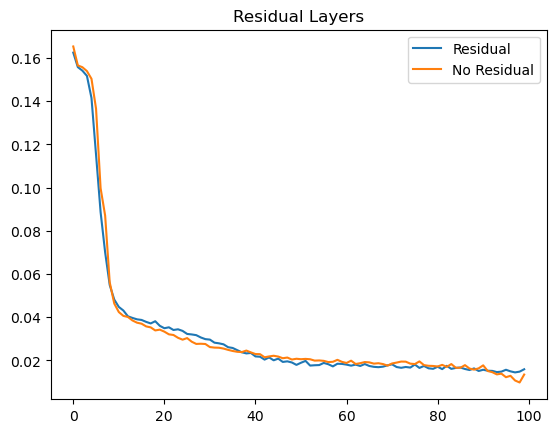

In [2]:
### residual layer
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Residual
sim_model_res = DataCenterModel(skip_connections=True)
sim_model_res.to(device)
sim_model_res.train()
# NoRes
sim_model_nores = DataCenterModel(skip_connections=False)
sim_model_nores.to(device)
sim_model_nores.train()
# large

print('')
# Trains model
sim_model_res, loss_record_res = train_model(sim_model_res,epochs=100,lr=1e-4,batch_size=512,verbose=False)
print('Residual Done')
sim_model_nores, loss_record_nores = train_model(sim_model_nores,epochs=100,lr=1e-4,batch_size=512,verbose=False)
print('No Residual Done')

starting_epoch = 0
plt.title('Residual Layers')
plt.plot(range(len(loss_record_res[starting_epoch:])),loss_record_res[starting_epoch:],label='Residual')
plt.plot(range(len(loss_record_nores[starting_epoch:])),loss_record_nores[starting_epoch:],label='No Residual')
plt.legend()

In [2]:
# Makes data center model, a neural network
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# small
sim_model_small = DataCenterModel(st_dim_hidden=512,st_dim_output=128)
sim_model_small.to(device)
sim_model_small.train()
# medium
sim_model_medium = DataCenterModel(st_dim_hidden=512,st_dim_output=512)
sim_model_medium.to(device)
sim_model_medium.train()
# large
sim_model_large = DataCenterModel(st_dim_hidden=512,st_dim_output=1024)
sim_model_large.to(device)
sim_model_large.train()
print('')

In [3]:
# Trains model
sim_model_small, loss_record_small = train_model(sim_model_small,epochs=50,lr=1e-4,batch_size=512,verbose=False)
print('Small Done')
sim_model_medium, loss_record_medium = train_model(sim_model_medium,epochs=50,lr=1e-4,batch_size=512,verbose=False)
print('Medium Done')
sim_model_large, loss_record_large = train_model(sim_model_large,epochs=50,lr=1e-4,batch_size=512,verbose=False)
print('Large Done')

c:\Users\qtcc\miniconda3\envs\rl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Small Done
Medium Done
Large Done


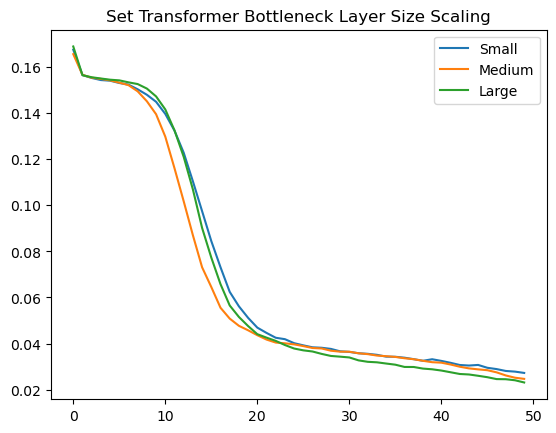

In [5]:
starting_epoch = 0
plt.title('Set Transformer Bottleneck Layer Size Scaling')
plt.plot(range(len(loss_record_small[starting_epoch:])),loss_record_small[starting_epoch:],label='Small')
plt.plot(range(len(loss_record_medium[starting_epoch:])),loss_record_medium[starting_epoch:],label='Medium')
plt.plot(range(len(loss_record_large[starting_epoch:])),loss_record_large[starting_epoch:],label='Large')
plt.legend()

In [6]:
predictions = []
X = simulator_input
Y = simulator_output
work_feature_dict = get_workload_mix_features_dict('../data/python_data/')
sim_model.eval()
for index in range(len(X)):
    # Grabs our sample from our training data 
    input_x = X[index]
    # converts it into things our model wants 
    # honestly average day in the world of PyTorch data formatting war crimes
    x_workloads = torch.tensor(work_feature_dict[input_x[0]]).unsqueeze(0).float().to(device)
    x_sim_config = torch.tensor(float(input_x[1])).to(device).unsqueeze(0)
    x_p = torch.tensor(float(input_x[2])).to(device).unsqueeze(0)
    x_r = torch.tensor(float(input_x[3])).to(device).unsqueeze(0)
    input_y = torch.tensor(float(Y[index])).unsqueeze(0).float().to(device)
    # Runs our sample through our network
    output = sim_model.forward(x_workloads,x_sim_config,x_p,x_r)
    predictions.append(output.item())


In [10]:
torch.save(sim_model,'models/model_v1.3.pth')

Text(0, 0.5, 'Cost')

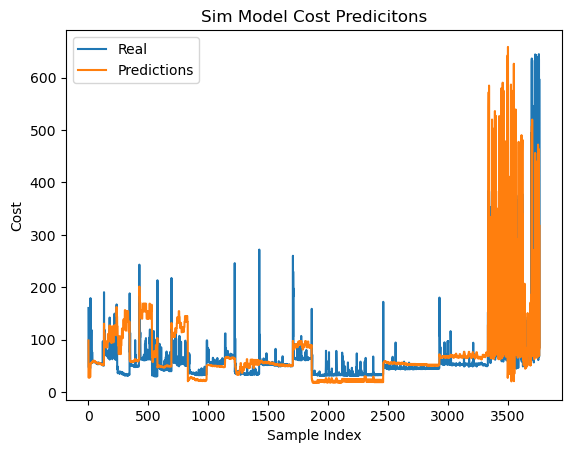

In [7]:
sim_output_floats = []
for output in simulator_output:
    sim_output_floats.append(float(output))
plt.plot(range(len(sim_output_floats)),sim_output_floats,label='Real')
plt.plot(range(len(predictions)),predictions,label='Predictions')
plt.title('Sim Model Cost Predicitons')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Cost')

Text(0, 0.5, 'Cost Difference')

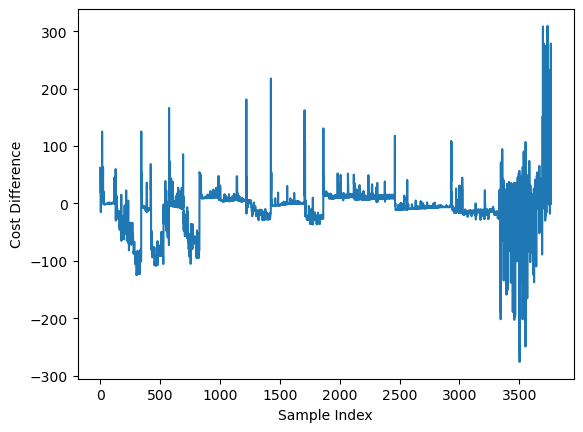

In [8]:
plt.plot(range(len(sim_output_floats)),np.array(sim_output_floats)-np.array(predictions),label='Difference')
plt.xlabel('Sample Index')
plt.ylabel('Cost Difference')

In [23]:
print(predictions)

[-0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.3670498728752136, -0.367049872